## NB03-Data Analysis

Input: the tidy tables from NB02 (`data/processed/movies.csv`, `data/processed/movie_genres.csv`).
Output: exploratory tables, figures saved to `docs/assets/` (used by the public website), and three central findings.

This notebook is exploratory: it summarises, groups, and plots the prepared data. It does not build predictive or machine-learning models, and it does not repeat the collection or preparation work.

The three findings I develop here, each answering part of the question:

1. Runtime - have popular movies grown longer over the decades?
2. Genres - which genres dominate, and how does that mix shift over time?
3. Rating - do average audience ratings drift across decades?

## 1. Load the prepared data


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("..") / "data" / "processed"
ASSETS_DIR = Path("..") / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

movies = pd.read_csv(PROCESSED_DIR / "movies.csv")
movie_genres = pd.read_csv(PROCESSED_DIR / "movie_genres.csv")

print(f"movies:        {len(movies)} rows")
print(f"movie_genres:  {len(movie_genres)} rows")
print(f"Year range:    {movies['year'].min()}-{movies['year'].max()}")
movies.head()

movies:        1220 rows
movie_genres:  3202 rows
Year range:    1960-2020


,movie_id,title,year,runtime,vote_average,vote_count,budget,revenue,original_language,decade
0,100,"Lock, Stock and Two Smoking Barrels",1998,105,8.097,7279,1350000.0,28356188.0,en,1990
1,10014,A Nightmare on Elm Street Part 2: Freddy's Rev...,1985,87,5.800,2141,3000000.0,30000121.0,en,1980
2,10020,Beauty and the Beast,1991,84,7.726,10772,25000000.0,424967620.0,en,1990
3,100402,Captain America: The Winter Soldier,2014,136,7.655,20180,170000000.0,714766572.0,en,2010
4,10072,A Nightmare on Elm Street 3: Dream Warriors,1987,96,6.717,2065,4450000.0,44793222.0,en,1980


## 2. How many movies per decade?

Before drawing conclusions, we check how much data supports each decade. If a decade has very few movies, we read its averages with caution.

decade
1960    200
1970    200
1980    200
1990    200
2000    200
2010    200
2020     20
Name: n_movies, dtype: int64


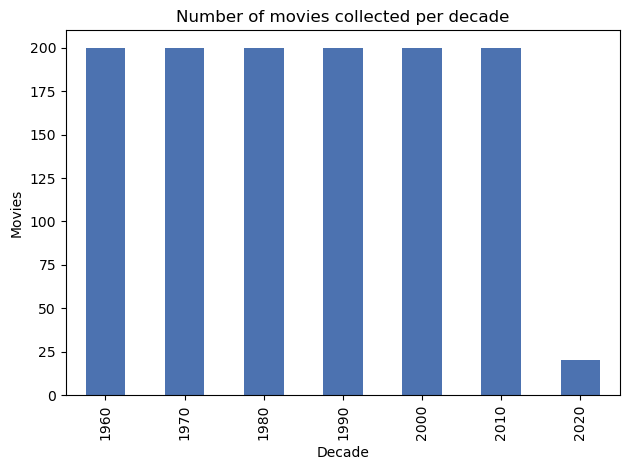

In [3]:
per_decade = movies.groupby("decade").size().rename("n_movies")
print(per_decade)

ax = per_decade.plot(kind="bar", color="#4C72B0")
ax.set_title("Number of movies collected per decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Movies")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "movies_per_decade.png", dpi=120)
plt.show()